# Machine Learning Assignment 1
# Aysel Zeynalova

In [51]:
# This is all the needed libraries for data preparation, visualization and model training.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Task: Identifying the Prediction Target


In [52]:
df= pd.read_csv('bank-additional.csv', sep=';')
print("The shape of the dataset is: ", df.shape)
print("The columns of the dataset are: ", df.columns)

The shape of the dataset is:  (4119, 21)
The columns of the dataset are:  Index(['age', 'job', 'marital', 'education', 'default', 'housing', 'loan',
       'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx',
       'cons.conf.idx', 'euribor3m', 'nr.employed', 'y'],
      dtype='str')


The target variable in the "bank-additional.csv" dataset is 'y', which indicates whether the client has subscribed to a term deposit or not. This variable is what we want to predict bases on the other features in the dataset. The values in this column are binary, with 'yes' indicating that the client has subscribed and 'no' indicating that they have not.The goal of a machine learning model trained on this dataset would be to predict the likelihood of a client subscribing to a term deposit based on the other features such as age, job, marital status, education, and previous contact information.

In [53]:
TARGET = 'y'
print("The target variable is: ", TARGET)
print(df[TARGET].value_counts())

The target variable is:  y
y
no     3668
yes     451
Name: count, dtype: int64


---
## Task: Data Loading and Initial Exploration

In [54]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [55]:
# Looking for different types of features in the dataset
num_cols = df.select_dtypes(include=['int64','float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
print("Numerical columns: ", num_cols)
print("Categorical columns: ", cat_cols)

Numerical columns:  Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')
Categorical columns:  Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


/var/folders/r4/vn3ch_fx47ngx_c7jfd69fjc0000gn/T/ipykernel_20017/346558164.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


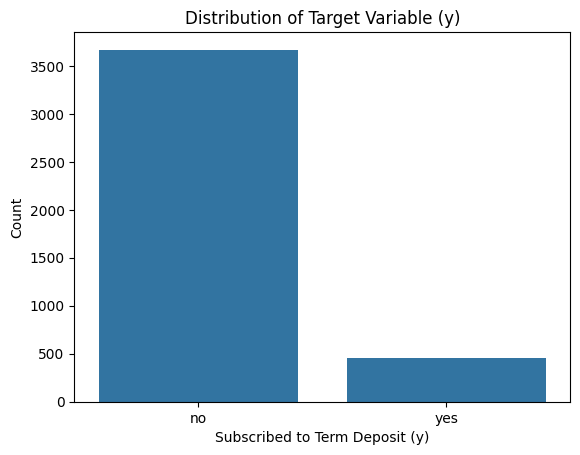

In [56]:
# Visualizing the distribution of the target variable
sns.countplot(x=TARGET, data=df)
plt.title('Distribution of Target Variable (y)')
plt.xlabel('Subscribed to Term Deposit (y)')
plt.ylabel('Count')
plt.show()

In [57]:
print(f'The percentage of clients who subscribed to a term deposit: {df[TARGET].value_counts(normalize=True)["yes"]:.2%}')

The percentage of clients who subscribed to a term deposit: 10.95%


The target is highly imbalanced, with a majority of clients not subscribing to a term deposit. This imbalance can pose challenges for machine learning models, as they may be biased towards predicting the majority class (not subscribing) and may struggle to accurately predict the minority class (subscribing).

In [58]:
# Checking for explicit missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)

Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [59]:
# Checking for implicit missing values (e.g., 'unknown' in categorical columns)
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of 'unknown' values in categorical columns:  {unknown_values},({(unknown_values/len(df)*100).__round__(2)}%)\n")


Count of 'unknown' values in categorical columns:  job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64,(job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [60]:
# Special sentinel in pdays: 999 means client was not previously contacted
print(f'\npdays == 999: {(df["pdays"]==999).sum()} ({(df["pdays"]==999).mean()*100:.1f}%)')


pdays == 999: 3959 (96.1%)


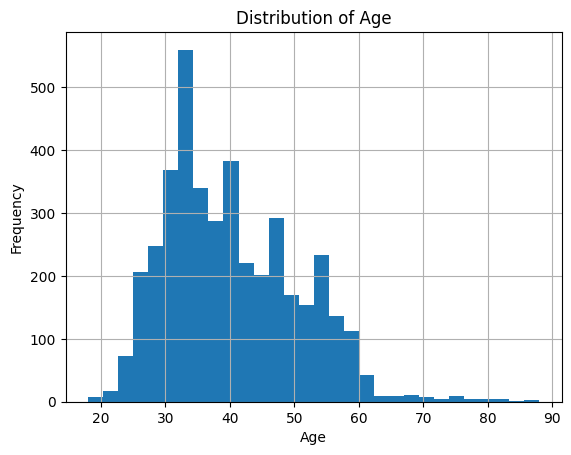

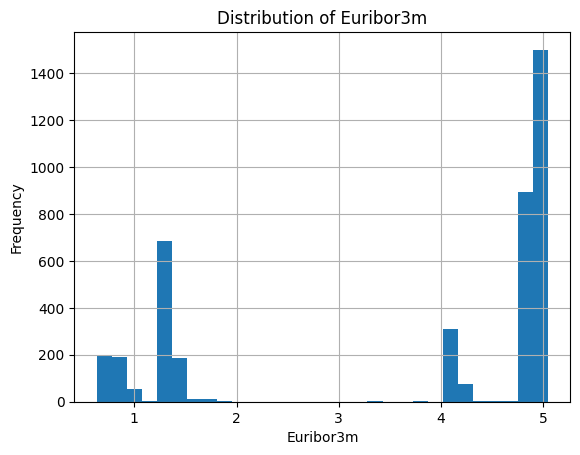

In [61]:
# Distribution of age

df['age'].hist(bins=30)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

# Distribution of euribor3m
df['euribor3m'].hist(bins=30)
plt.title('Distribution of Euribor3m')
plt.xlabel('Euribor3m')
plt.ylabel('Frequency')
plt.show()


The age distribution shows that most clients are between 30 and 60 years old, with a peak around 40-50 years. The euribor3m distribution is right-skewed, with most values concentrated at the lower end (0-5) and a long tail extending to higher values. This suggests that most clients were contacted during periods of low interest rates, which could influence their likelihood of subscribing to a term deposit.

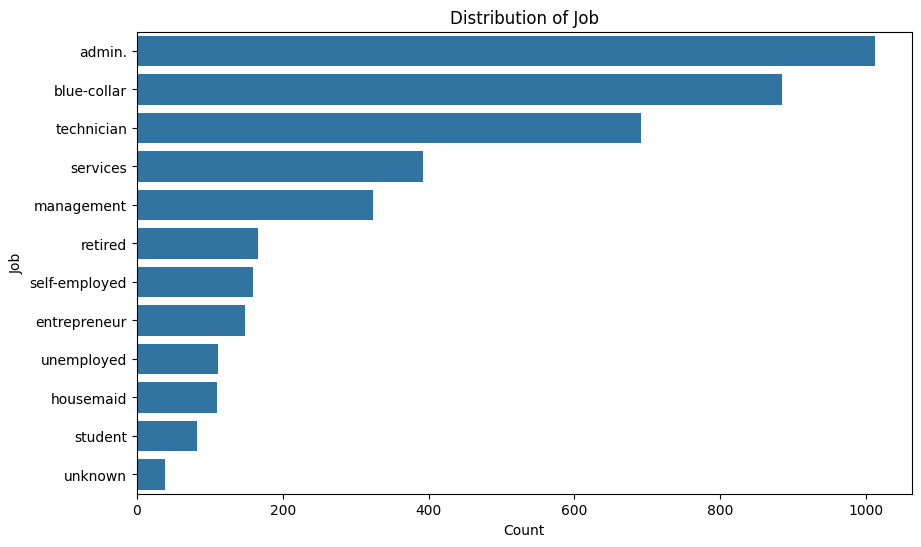

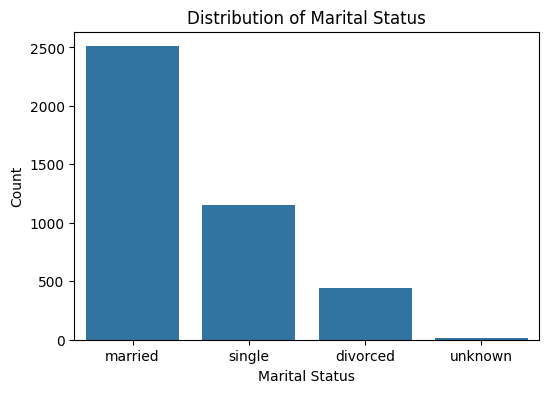

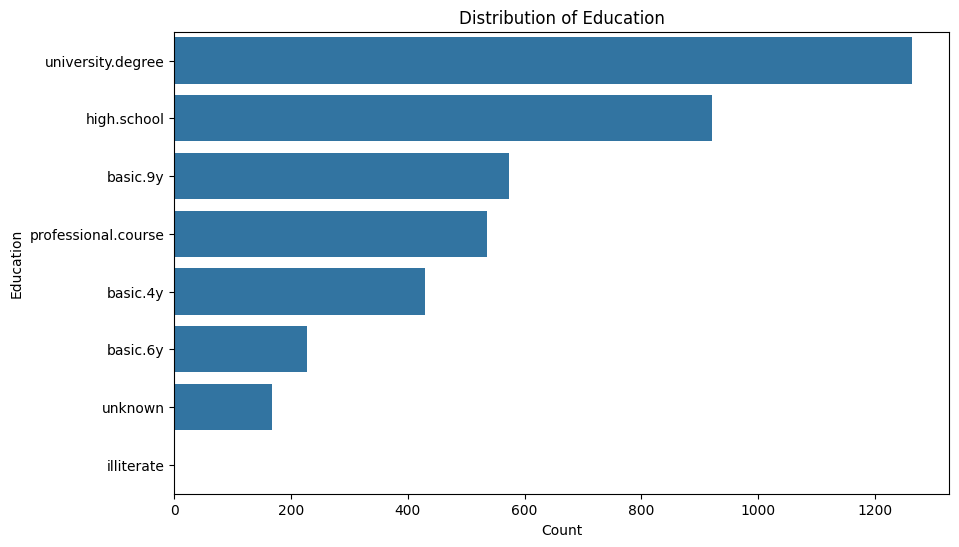

In [62]:
# Distribution of job
plt.figure(figsize=(10,6))
sns.countplot(y='job', data=df, order=df['job'].value_counts().index)
plt.title('Distribution of Job')
plt.xlabel('Count')
plt.ylabel('Job')
plt.show()

# Distribution of marital status
plt.figure(figsize=(6,4))
sns.countplot(x='marital', data=df, order=df['marital'].value_counts().index)
plt.title('Distribution of Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Count')
plt.show()

# Distribution of education
plt.figure(figsize=(10,6))
sns.countplot(y='education', data=df, order=df['education'].value_counts().index)
plt.title('Distribution of Education')
plt.xlabel('Count')
plt.ylabel('Education')
plt.show()

In [63]:
# The job distribution shows that the most common occupations among clients are "blue-collar", "management", and "technician". The marital status distribution indicates that most clients are married, followed by single and divorced. The education distribution reveals that the majority of clients have a secondary education, with fewer clients having primary or tertiary education. These distributions provide insights into the demographic characteristics of the clients, which may influence their likelihood of subscribing to a term deposit.

### Special Consideration for 'pdays' Feature
The variable 'pdays' has a special sentinel value of 999, which indicates that the client was not previously contacted.This creates extreme skewness. This means that for clients with pdays=999, we do not have information about their previous contact history. This can be considered as a form of missing data, and it may require special handling during data preprocessing and model training to ensure that the model can effectively learn from the available information without being biased by the presence of these sentinel values. We will handle this by creating a new binary feature that indicates whether the client was previously contacted or not, and then replacing 999 with 0 in the pday column. This way we can retain all the data without losing any information due to imputation or deletion.

---
#  Task: Data Splitting

We will use 70% of the data for training, 15% for validation, and 15% for testing. This split allows us to train our model on a substantial portion of the data while reserving enough data for evaluating the model's performance on unseen data (validation and test sets). The validation set will be used for tuning hyperparameters and making decisions about model selection, while the test set will provide an unbiased evaluation of the final model's performance.

In [64]:
X=df.drop(columns=[TARGET])
y=df[TARGET]

# first split into training and temporary sets (70% train, 30% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# second split the temporary set into validation and test sets (15% each)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f'Training set size: {X_train.shape[0]} samples')
print(f'Validation set size: {X_val.shape[0]} samples')
print(f'Test set size: {X_test.shape[0]} samples')

Training set size: 2883 samples
Validation set size: 618 samples
Test set size: 618 samples


The training set is the largest portion (70%) to ensure that the model has enough data to learn from and capture the underlying patterns in the data. The validation set (15%) is used to tune hyperparameters and make decisions about model selection without overfitting to the training data. Finally, the test set (15%) provides an unbiased evaluation of the final model's performance on unseen data, allowing us to assess how well the model generalizes to new instances. This split strikes a balance between having enough data for training while still reserving sufficient data for reliable validation and testing.

Stratification is important in this context because the target variable 'y' is imbalanced, with a majority of clients not subscribing to a term deposit. By using stratified sampling during the train-test split, we ensure that the proportion of classes (subscribed vs. not subscribed) is maintained in each of the training, validation, and test sets. This helps to prevent bias in the model training and evaluation process, as it allows the model to learn from a representative distribution of the classes and provides a more accurate assessment of its performance on unseen data.

The data split must occur immediately after defining the feature matrix (x) and target variable (y), and before performing any data preprocessing steps such as handling missing values, encoding categorical variables, or feature scaling. This is important to prevent data leakage, which can occur if information from the validation or test sets is inadvertently used during the training process. By splitting the data first, we ensure that the model is trained only on the training set and that the validation and test sets remain completely unseen until the evaluation phase, providing a more accurate assessment of the model's performance on new data.

---
# Task: Managing Missing Values

In [65]:
# Checking for explicit missing values in the dataset
missing_values = df.isnull().sum()
print("Missing values in each column:\n", missing_values)


Missing values in each column:
 age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64


In [66]:
# Checking for implicit missing values (e.g., 'unknown' in categorical columns)
unknown_values = df[cat_cols].apply(lambda x: (x == 'unknown').sum())
print(f"Count of 'unknown' values in categorical columns:  {unknown_values},({(unknown_values/len(df)*100).__round__(2)}%)\n")

Count of 'unknown' values in categorical columns:  job             39
marital         11
education      167
default        803
housing        105
loan           105
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64,(job             0.95
marital         0.27
education       4.05
default        19.50
housing         2.55
loan            2.55
contact         0.00
month           0.00
day_of_week     0.00
poutcome        0.00
y               0.00
dtype: float64%)



In [67]:
# Handling the 'pdays' feature with sentinel value 999

def handle_pdays(X):
    X = X.copy()
    X['was_contacted_before'] = (X['pdays'] != 999).astype(int)
    X['pdays'] = X['pdays'].replace(999, 0)
    return X

X_train = handle_pdays(X_train)
X_val = handle_pdays(X_val)
X_test = handle_pdays(X_test)

# Quantify the extent of missingness for each affected variable.

print('was_contacted_before value counts in training set:\n', X_train['was_contacted_before'].value_counts())

cat_cols = X_train.select_dtypes(include=['object', 'string']).columns
print('unknown values in categorical columns after handling pdays:\n', X_train[cat_cols].apply(lambda x: (x == 'unknown').sum()))

was_contacted_before value counts in training set:
 was_contacted_before
0    2764
1     119
Name: count, dtype: int64
unknown values in categorical columns after handling pdays:
 job             25
marital          7
education      112
default        577
housing         65
loan            65
contact          0
month            0
day_of_week      0
poutcome         0
dtype: int64


For the 'pdays' feature, we have created a new binary feature called 'was_contacted_before' to indicate whether the client was previously contacted or not. This allows us to retain all the information without losing any data due to imputation or deletion. We then replaced the sentinel value of 999 with 0 in the 'pdays' column, which allows us to treat it as a numerical feature while still capturing the information about previous contact.

For the categorical features with 'unknown' values, we can treat 'unknown' as a separate category. This is because 'unknown' may carry meaningful information about the clients who did not provide certain information, and it allows us to retain all the data without losing any samples due to imputation or deletion. By treating 'unknown' as its own category, we can also capture any patterns or associations that may exist between the 'unknown' category and the target variable, which could be valuable for model training and prediction.

All transformations are derived from the training set structure only here, since the strategy involves eno statistical estimation, there is no fitting step that could lead to data leakage. However, for consistency in a sklearn Pipeline, these would be fit on train.

---
# Task: Encoding Categorical Variables